# Seguimiento semanal

## Qué responde este notebook

Durante la temporada, `weekly/wr/src/pipeline.py` corre dos veces por semana: antes de los partidos
para predecir y, cuando ya se jugaron, para evaluar. Este notebook explica cómo se sabe si el modelo
se está desviando y cuándo se reentrena
([`docs/decisions/0006-seguimiento-semanal.md`](../../../docs/decisions/0006-seguimiento-semanal.md)):

1. Qué guarda cada corrida, y cómo se reproduce una predicción emitida.
2. Qué revisa el flujo en los datos antes de predecir, y qué lo detiene.
3. Contra qué límites se compara cada semana, y por qué esos.
4. Cómo van las semanas 1-5 de 2026 en el historial (`weekly/wr/outputs/tracking.csv`).
5. Qué se hace con una alerta.

Los modelos y sus límites vienen de
[`6.1_modelo_final_y_temporada_actual.ipynb`](6.1_modelo_final_y_temporada_actual.ipynb). Este
notebook solo lee: las corridas las hace el flujo semanal, y cada una deja sus filas en el historial.

In [1]:
import sys
sys.path.insert(0, "../src")
import features, modeling, experimentos, seguimiento, pipeline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 90)
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

SALIDAS = Path("../outputs")
modelos = modeling.cargar_modelos("../models")
VARIABLES = modelos["receptions"]["variables"]
HIPERPARAMETROS = {t: json.loads(Path(f"../models/{t}_metadata.json").read_text())["hiperparametros"]
                   for t in modeling.TARGETS}

## 1. Qué guarda cada corrida

| Archivo (en `weekly/wr/outputs/`) | Cuándo se escribe | Qué tiene |
|---|---|---|
| `{temporada}/predicciones_semana_N.csv` | Semana pendiente | La predicción emitida: una fila por receptor de la alineación. Si se vuelve a correr antes del primer partido, se reemplaza; una vez que empieza la semana, ya no se toca |
| `{temporada}/variables_semana_N.csv` | Semana pendiente | Las 25 variables con que se hizo esa predicción, en el orden del modelo |
| `{temporada}/evaluacion_semana_N.csv` | Semana jugada | Predicción y valor real por receptor, y si la predicción es la emitida o una reconstruida |
| `{temporada}/metricas_semana_N.csv` | Semana jugada | Métricas de la semana, con las de referencia de validación y prueba |
| `tracking.csv` | Cada corrida | Una fila por corrida y resultado; nunca se reescribe, solo se agregan filas |

Al evaluar una semana jugada se usa la predicción emitida, la que estaba disponible antes de los
partidos, y no una recalculada después. Si no existe (las semanas 1-4 de 2026, anteriores a este
flujo), se recalcula con los modelos vigentes y queda marcada como `reconstruida`.

La huella del archivo de variables (los primeros 16 caracteres de su SHA-256) queda en el
historial. Con ese archivo y los modelos guardados, la predicción se reproduce exacta. Se
comprueba con la semana 5, ya emitida y todavía sin jugarse:

In [2]:
carpeta = SALIDAS / "2026"
tracking = seguimiento.leer_tracking(SALIDAS / "tracking.csv")
emitida = pd.read_csv(carpeta / "predicciones_semana_5.csv")
variables_5 = pd.read_csv(carpeta / "variables_semana_5.csv")
fila = tracking[(tracking["season"] == 2026) & (tracking["week"] == 5) & (tracking["estado"] == "pendiente")].iloc[-1]
print(f"semana 5: {len(emitida)} receptores, {len(variables_5.columns) - len(seguimiento.COLUMNAS_ID)} variables")
print(f"huella en el historial: {fila['huella_variables']} | huella del archivo: {seguimiento.huella(carpeta / 'variables_semana_5.csv')}")

reproducida = modeling.predecir(variables_5, modelos).round(3)
cruce = reproducida.merge(emitida, on="player_id", suffixes=("", "_emitida"))
identica = len(cruce) == len(emitida) and all(
    (cruce[f"{t}_pred"] == cruce[f"{t}_pred_emitida"]).all() for t in modeling.TARGETS)
print(f"prediccion reproducida con el archivo de variables y los modelos guardados, identica: {identica}")

semana 5: 186 receptores, 25 variables
huella en el historial: 76991428c3624f96 | huella del archivo: 76991428c3624f96
prediccion reproducida con el archivo de variables y los modelos guardados, identica: True


**Lectura.** La semana 5 quedó emitida con 186 receptores y sus 25 variables. La huella del historial
coincide con la del archivo, y la predicción que se reproduce con ese archivo y los modelos guardados
es idéntica a la emitida. Así se puede auditar después qué se predijo y con qué datos.

## 2. Chequeos de calidad antes de predecir

Las seis dimensiones de calidad de [`docs/data/DATASHEET.md`](../../../docs/data/DATASHEET.md) se
auditaron una vez, al construir los datos (etapa 1). El flujo semanal las vuelve a revisar en cada
corrida con `seguimiento.chequear_calidad`, sobre la tabla de la semana. Lo que invalida la
predicción detiene la corrida sin escribir nada: un jugador repetido, una variable del modelo
ausente o vacía, un equipo sin receptores en la alineación o las estadísticas de la semana anterior
sin cargar. Lo demás queda como advertencia en el historial.

Por ejemplo, si la alineación de un equipo todavía no se publica, sus receptores no tendrían
predicción: la corrida se detiene y dice qué equipo falta. Una semana a medias (con partidos ya
jugados) también se detiene, antes de cualquier chequeo (`pipeline.estado_de_la_semana`).

Los chequeos de la semana 5 (pendiente) y de la semana 4 (jugada), que agrega los de exactitud:

In [3]:
semana_5, historico_5 = pipeline.tabla_de_la_semana(2026, 5, "pendiente")
semana_4, historico_4 = pipeline.tabla_de_la_semana(2026, 4, "jugada")
chequeos = pd.concat({
    "semana 5": seguimiento.chequear_calidad(semana_5, historico_5, VARIABLES, "pendiente",
                                             pipeline.juegos_de_la_semana(2026, 5)),
    "semana 4": seguimiento.chequear_calidad(semana_4, historico_4, VARIABLES, "jugada",
                                             pipeline.juegos_de_la_semana(2026, 4)),
}, names=["semana", None]).reset_index(level=0)
display(chequeos)

print("valores fuera del rango historico:")
for nombre, (tabla_semana, historico) in {"semana 5": (semana_5, historico_5), "semana 4": (semana_4, historico_4)}.items():
    for var in VARIABLES:
        minimo, maximo = historico[var].min(), historico[var].max()
        for r in tabla_semana[(tabla_semana[var] < minimo) | (tabla_semana[var] > maximo)].itertuples():
            print(f"  {nombre}: {r.player_display_name} ({r.team}), {var} = {getattr(r, var):.4g}; "
                  f"rango 2016 a la semana anterior: {minimo:.4g} a {maximo:.4g}")

,semana,dimension,chequeo,nivel,ok,detalle
0,semana 5,Unicidad,una fila por jugador,bloquea,True,
1,semana 5,Completitud,variables de los modelos presentes,bloquea,True,
2,semana 5,Completitud,ninguna variable 100% vacia,bloquea,True,
3,semana 5,Completitud,vacios a no mas de 10 puntos sobre el historico de la semana 5,advierte,True,
4,semana 5,Consistencia,equipos de la tabla en el calendario de la semana,advierte,True,
5,semana 5,Consistencia,cada equipo que juega tiene receptores,bloquea,True,
6,semana 5,Validez,valores dentro del rango historico,advierte,False,depth_team (1 filas)
7,semana 5,Vigencia,estadisticas de la semana anterior cargadas,bloquea,True,
8,semana 5,Vigencia,lineas de apuestas en cada partido,advierte,True,
0,semana 4,Unicidad,una fila por jugador,bloquea,True,


valores fuera del rango historico:
  semana 5: Ricky Pearsall (SF), depth_team = 9; rango 2016 a la semana anterior: 1 a 8
  semana 4: Marvin Mims Jr. (DEN), air_yards_share_last3_avg = -0.1184; rango 2016 a la semana anterior: -0.1147 a 0.9687


**Lectura.** En las dos semanas pasan todos los chequeos que bloquean, y en la semana 4 también los
de exactitud. Queda una advertencia de validez en cada una, por un solo receptor con un valor apenas
fuera de lo visto desde 2016:

- En la semana 5, Ricky Pearsall aparece noveno en la alineación de SF, y el máximo histórico es 8.
- En la semana 4, Marvin Mims Jr. tiene participación negativa en yardas aéreas. En sus últimos
  partidos, los pases que le lanzaron cayeron en promedio detrás de la línea de golpeo.

Son valores reales. La advertencia sirve para que no pasen sin verse.

Para ver que los chequeos detienen la corrida, se altera a propósito la tabla de la semana 5: se
repite un receptor, se borra la edad y se vacía el total implícito. Después, por separado, se deja
sin dato `depth_team` en 30% de las filas: eso solo advierte, porque el modelo puede predecir sin
esa variable.

In [4]:
juegos_5 = pipeline.juegos_de_la_semana(2026, 5)
alterada = pd.concat([semana_5, semana_5.iloc[[0]]]).drop(columns=["edad"])
alterada["total_implicito_equipo"] = np.nan
try:
    seguimiento.detener_si_bloquea(seguimiento.chequear_calidad(alterada, historico_5, VARIABLES, "pendiente", juegos_5))
except seguimiento.ChequeoBloqueante as error:
    print(error)

sin_depth = semana_5.copy()
sin_depth.loc[sin_depth.sample(frac=0.3, random_state=0).index, "depth_team"] = np.nan
resultado = seguimiento.chequear_calidad(sin_depth, historico_5, VARIABLES, "pendiente", juegos_5)
seguimiento.detener_si_bloquea(resultado)
print("\ncon depth_team vacio en 30% de las filas no se detiene; advertencias:")
print(seguimiento.advertencias(resultado))

la corrida se detiene, chequeos de calidad que invalidan la prediccion:
- Unicidad: una fila por jugador (1 jugadores repetidos: 00-0030279)
- Completitud: variables de los modelos presentes (edad)
- Completitud: ninguna variable 100% vacia (total_implicito_equipo)

con depth_team vacio en 30% de las filas no se detiene; advertencias:
vacios a no mas de 10 puntos sobre el historico de la semana 5: depth_team 30.1% (historico 7.9%); valores dentro del rango historico: depth_team (1 filas)


**Lectura.** La tabla alterada se detiene, y el mensaje nombra los tres problemas a la vez. Con
`depth_team` vacío en 30% de las filas la corrida sigue: en la semana 5 de las temporadas anteriores
esa variable estaba vacía en 7.9% de las filas, y la diferencia queda anotada como advertencia.

## 3. Límites de control

### Qué es una ventana

Una sola semana tiene unos 150 receptores con partido y su error varía mucho de una a otra. Por eso
el flujo mide las cuatro últimas semanas jugadas juntas, una **ventana**, y compara su métrica
principal, su sesgo y su pendiente de calibración contra unos límites.

Los límites salen de repetir la operación en 2021-2025, con el walk-forward de
[`5.1_estabilidad_temporal.ipynb`](5.1_estabilidad_temporal.ipynb) y los hiperparámetros guardados
con cada modelo. Por ejemplo, para la ventana
5-8 de 2025 se entrena con 2016-2024, se predicen las semanas 5 a 8 de 2025 y se miden las cuatro
juntas:

In [5]:
N_SERIES = 3 * len(modeling.TARGETS)
ANIOS = [2021, 2022, 2023, 2024, 2025]
wr = features.construir_tabla_modelado(range(2016, 2027))
X = wr[VARIABLES]
ventanas = {
    target: experimentos.ventanas_walk_forward(
        wr, X, wr[target], lambda: XGBRegressor(**HIPERPARAMETROS[target]), ANIOS, target=target)
    for target in modeling.TARGETS
}
v = ventanas["receiving_yards"]
print(v[(v["season"] == 2025) & (v["semana_final"] == 8)].round(4).to_string(index=False))
print(f"\nventanas por resultado: {len(v)} (de la 1-4 a la 15-18 en cada temporada)")

 season  semana_inicial  semana_final   n    rmse   sesgo  pendiente_calibracion
   2025               5             8 527 28.0011 -2.1051                 1.0267

ventanas por resultado: 75 (de la 1-4 a la 15-18 en cada temporada)


**Lectura.** La ventana 5-8 de 2025 junta 527 filas: RMSE de 28.00 yardas, sesgo de −2.11 (el modelo
predijo de menos) y pendiente de 1.03. Cada temporada da 15 ventanas, de la 1-4 a la 15-18.

En cada resultado se juntan 75 ventanas, y los límites son percentiles de esas ventanas. La métrica
principal solo alerta hacia arriba, porque un error menor no es un problema; el sesgo y la pendiente
alertan de los dos lados. La figura muestra el sesgo de las 75 ventanas, sus límites y la ventana
1-4 de 2026:

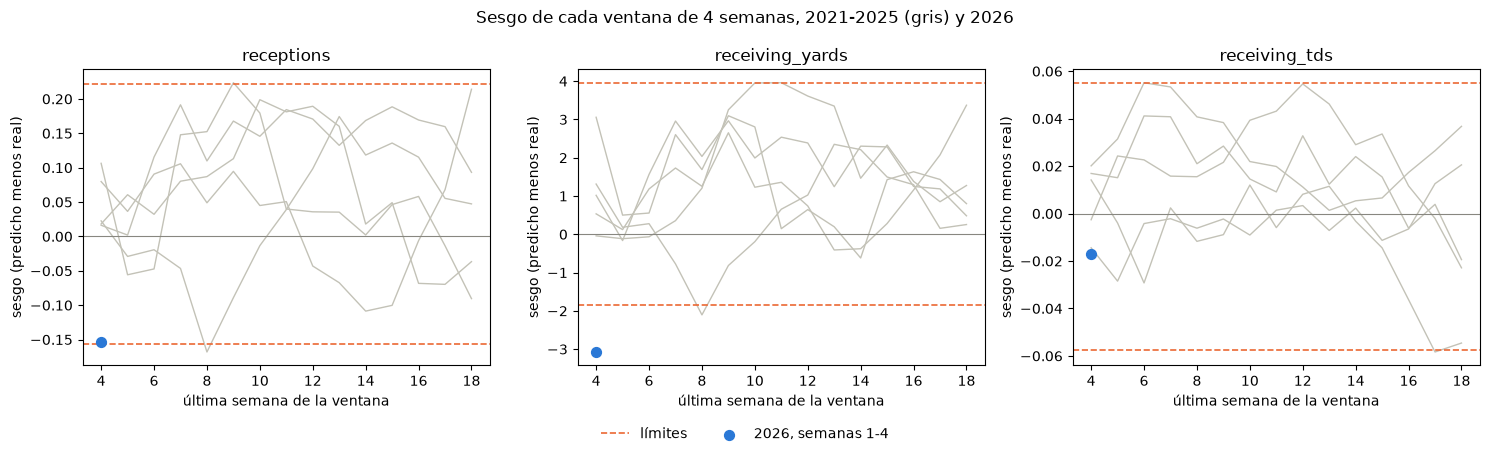

,minimo_2021_2025,limite_inferior,limite_superior,maximo_2021_2025,2026_semanas_1_4
receptions,-0.1680,-0.1558,0.2216,0.2235,-0.1532
receiving_yards,-2.1051,-1.8400,3.9578,3.9590,-3.0743
receiving_tds,-0.0583,-0.0576,0.0550,0.0551,-0.0171


In [6]:
tracking_reciente = seguimiento.ultimas_corridas(tracking)
fila_2026 = tracking_reciente[(tracking_reciente["season"] == 2026) & (tracking_reciente["week"] == 4)
                              & (tracking_reciente["estado"] == "jugada")].set_index("target")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, target in zip(axes, modeling.TARGETS):
    v = ventanas[target]
    for anio, datos in v.groupby("season"):
        ax.plot(datos["semana_final"], datos["sesgo"], color=GRIS_CLARO, linewidth=1)
    limites = modelos[target]["limites_seguimiento"]["metricas"]["sesgo"]
    for lado in ("inferior", "superior"):
        ax.axhline(limites[lado], color=NARANJA, linestyle="--", linewidth=1.2,
                   label="límites" if lado == "inferior" else None)
    ax.axhline(0, color=GRIS, linewidth=0.8)
    ax.scatter([4], [fila_2026.loc[target, "ventana_sesgo"]], color=AZUL, zorder=3, s=50, label="2026, semanas 1-4")
    ax.set_title(target)
    ax.set_xlabel("última semana de la ventana")
    ax.set_ylabel("sesgo (predicho menos real)")
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=2, frameon=False)
fig.suptitle("Sesgo de cada ventana de 4 semanas, 2021-2025 (gris) y 2026")
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

pd.DataFrame({
    target: {"minimo_2021_2025": ventanas[target]["sesgo"].min(),
             "limite_inferior": modelos[target]["limites_seguimiento"]["metricas"]["sesgo"]["inferior"],
             "limite_superior": modelos[target]["limites_seguimiento"]["metricas"]["sesgo"]["superior"],
             "maximo_2021_2025": ventanas[target]["sesgo"].max(),
             "2026_semanas_1_4": fila_2026.loc[target, "ventana_sesgo"]}
    for target in modeling.TARGETS
}).T.round(4)

**Lectura.** Repartir el 5% entre nueve series deja cada límite entre la ventana más extrema de
2021-2025 y la siguiente, de cada lado: los límites encierran casi todo lo visto en cinco temporadas.
La ventana 1-4 de 2026 queda
por debajo del límite inferior en yardas: −3.07 contra −1.84. Ninguna ventana de 2021-2025 tuvo un
sesgo tan negativo; la más baja fue la 5-8 de 2025, con −2.11. En recepciones queda justo dentro
(−0.153 contra un límite de −0.156) y en touchdowns, en la zona de siempre.

### Por qué estos límites

Una regla de alerta sirve si casi nunca suena cuando el modelo está bien. Se prueba con las cinco
temporadas del walk-forward, en las que el modelo cumplió los requisitos cada año
([`5.1_estabilidad_temporal.ipynb`](5.1_estabilidad_temporal.ipynb)). Para cada temporada, los
límites se calculan con las otras cuatro y se cuenta cuántas veces habría sonado una alerta en ella.
Se comparan dos decisiones:

- **Percentiles.** Con 2.5 y 97.5 por serie, cada una de las nueve series (tres resultados por tres
  métricas) tiene 5% de falsas alarmas, y juntas muchas más. Con Bonferroni, el 5% se reparte entre
  las nueve, como en [`docs/decisions/0004-metricas-de-seleccion.md`](../../../docs/decisions/0004-metricas-de-seleccion.md).
- **Persistencia.** Una alerta persistente pide revisar el modelo. Si cuenta como persistente estar
  fuera en dos ventanas seguidas, la segunda casi no agrega evidencia, porque comparten tres de sus
  cuatro semanas. La alternativa es exigir que también esté fuera la ventana que termina cuatro
  semanas antes, la primera sin semanas en común.

In [7]:
def alertas_dejando_un_anio(ventanas, n_series, previa_a):
    """Para cada temporada: limites con las otras y alertas en cada una de sus ventanas, en orden.
    `previa_a`: cuantas semanas antes termina la ventana contra la que se revisa la persistencia."""
    filas = []
    for target, v in ventanas.items():
        principal = modeling.METRICA_PRINCIPAL[target]
        for anio in ANIOS:
            limites = experimentos.limites_de_seguimiento(v[v["season"] != anio], n_series)
            alertas = {}
            for r in v[v["season"] == anio].sort_values("semana_final").itertuples():
                valores = {principal: getattr(r, principal), "sesgo": r.sesgo, "pendiente_calibracion": r.pendiente_calibracion}
                alertas[r.semana_final] = seguimiento.evaluar_alertas(valores, limites, alertas.get(r.semana_final - previa_a, ""))
                for metrica in valores:
                    texto = [a for a in alertas[r.semana_final].split("; ") if a.split(" ")[0] == metrica]
                    filas.append({"target": target, "metrica": metrica, "season": anio, "semana_final": r.semana_final,
                                  "fuera": bool(texto), "persistente": bool(texto) and texto[0].endswith("(persistente)")})
    return pd.DataFrame(filas)

reglas = {
    "percentiles 2.5/97.5, ventanas seguidas": (1, 1),
    "percentiles 2.5/97.5, sin semanas en común": (1, 4),
    "Bonferroni, ventanas seguidas": (N_SERIES, 1),
    "Bonferroni, sin semanas en común (vigente)": (N_SERIES, 4),
}
resumen, detalle = {}, {}
for nombre, (n_series, previa_a) in reglas.items():
    d = alertas_dejando_un_anio(ventanas, n_series, previa_a)
    por_temporada = d.groupby("season")[["fuera", "persistente"]].any()
    detalle[nombre] = d
    resumen[nombre] = {"ventanas fuera (%)": 100 * d["fuera"].mean(),
                       "temporadas con alguna alerta (de 5)": int(por_temporada["fuera"].sum()),
                       "temporadas con alguna alerta persistente (de 5)": int(por_temporada["persistente"].sum())}
display(pd.DataFrame(resumen).T.round(1))

vigente = detalle["Bonferroni, sin semanas en común (vigente)"]
print("alertas persistentes con la regla vigente:")
print(vigente[vigente["persistente"]][["target", "metrica", "season", "semana_final"]].to_string(index=False))

,ventanas fuera (%),temporadas con alguna alerta (de 5),temporadas con alguna alerta persistente (de 5)
"percentiles 2.5/97.5, ventanas seguidas",8.0,5.0,5.0
"percentiles 2.5/97.5, sin semanas en común",8.0,5.0,3.0
"Bonferroni, ventanas seguidas",5.5,5.0,4.0
"Bonferroni, sin semanas en común (vigente)",5.5,5.0,1.0


alertas persistentes con la regla vigente:
    target               metrica  season  semana_final
receptions pendiente_calibracion    2024            18


**Lectura.** Con percentiles 2.5/97.5 y dos ventanas seguidas, las cinco temporadas habrían tenido
alguna alerta persistente, aunque el modelo cumplió los requisitos en todas: con esa regla se
revisaría el modelo cada temporada sin motivo. Cada corrección ayuda por separado (3 y 4 temporadas
de 5). Juntas dejan una sola: la pendiente de recepciones en la semana 18 de 2024, la última de esa
temporada.

Las alertas sueltas siguen apareciendo en todas las temporadas: 5.5% de las combinaciones de ventana
y métrica quedan fuera. Por eso una alerta suelta solo se anota, y lo que pide revisar el modelo es
la persistente.

## 4. Las semanas 1-5 de 2026 en el historial

Las semanas 1-4 se cargaron al historial con la predicción reconstruida (no había predicción emitida
con estos modelos), y la 5 tiene ya su predicción emitida. Para cada semana y resultado se toma la
corrida más reciente; `valor` es la métrica principal de la semana y `ventana_*`, la de las cuatro
últimas semanas, que existe desde la semana 4.

In [8]:
historial = tracking_reciente[(tracking_reciente["season"] == 2026) & (
    ((tracking_reciente["week"] <= 4) & (tracking_reciente["estado"] == "jugada"))
    | ((tracking_reciente["week"] == 5) & (tracking_reciente["estado"] == "pendiente")))]
columnas = ["week", "estado", "target", "origen_prediccion", "n_wr", "valor", "referencia_validacion", "sesgo",
            "pendiente_calibracion", "ventana", "ventana_valor", "ventana_sesgo", "ventana_pendiente", "alertas"]
display(historial[columnas].round(4).fillna(""))
print("advertencias de calidad por semana:")
for (week, estado), texto in historial.groupby(["week", "estado"])["advertencias"].first().items():
    print(f"  semana {week} ({estado}): {texto if isinstance(texto, str) else 'ninguna'}")

,week,estado,target,origen_prediccion,n_wr,valor,referencia_validacion,sesgo,pendiente_calibracion,ventana,ventana_valor,ventana_sesgo,ventana_pendiente,alertas
0,1,jugada,receiving_tds,reconstruida,151,0.5949,0.6128,-0.025,1.2833,,,,,
1,1,jugada,receiving_yards,reconstruida,151,28.5661,29.5002,-1.8337,1.0049,,,,,
2,1,jugada,receptions,reconstruida,151,1.8146,1.9315,-0.0944,0.9533,,,,,
3,2,jugada,receiving_tds,reconstruida,152,0.6709,0.6128,-0.0081,1.5225,,,,,
4,2,jugada,receiving_yards,reconstruida,152,30.3854,29.5002,-2.2799,1.0407,,,,,
5,2,jugada,receptions,reconstruida,152,1.8646,1.9315,-0.0672,0.9331,,,,,
6,3,jugada,receiving_tds,reconstruida,154,0.6044,0.6128,-0.0276,0.8471,,,,,
7,3,jugada,receiving_yards,reconstruida,154,27.4815,29.5002,-2.8153,1.0819,,,,,
8,3,jugada,receptions,reconstruida,154,1.7927,1.9315,-0.1753,1.1372,,,,,
9,4,jugada,receiving_tds,reconstruida,151,0.6452,0.6128,-0.0075,0.6923,1-4,0.6288,-0.0171,1.0665,


advertencias de calidad por semana:
  semana 1 (jugada): valores dentro del rango historico: air_yards_share_last3_avg (1 filas); prediccion emitida encontrada: se recalculo con los modelos vigentes
  semana 2 (jugada): valores dentro del rango historico: receiving_yards_career_avg (1 filas), receiving_yards_last5_avg (1 filas); prediccion emitida encontrada: se recalculo con los modelos vigentes
  semana 3 (jugada): prediccion emitida encontrada: se recalculo con los modelos vigentes
  semana 4 (jugada): valores dentro del rango historico: air_yards_share_last3_avg (1 filas); prediccion emitida encontrada: se recalculo con los modelos vigentes
  semana 5 (pendiente): valores dentro del rango historico: depth_team (1 filas)


**Lectura.** Semana por semana, la métrica principal se mueve alrededor de la de validación: en yardas
va de 27.48 a 31.80 contra 29.50, y en recepciones de 1.79 a 2.02 contra 1.93. El sesgo, en cambio, es
negativo en las cuatro semanas y en los tres resultados: el modelo predice de menos. En yardas crece
de −1.83 en la semana 1 a −5.38 en la 4.

La ventana 1-4 da la única alerta: el sesgo de yardas. Es una alerta suelta. Sería persistente si la
ventana 5-8 también quedara fuera, y eso se sabrá cuando se evalúe la semana 8. La semana 5 ya tiene
su predicción emitida; será la primera que se evalúe tal como se emitió. Las advertencias de calidad
son los valores fuera de rango de la sección 2 y, en las semanas 1-4, la predicción reconstruida.

## 5. Qué se hace con una alerta

La política está en [`docs/decisions/0006-seguimiento-semanal.md`](../../../docs/decisions/0006-seguimiento-semanal.md):

- **Alerta** (una ventana fuera de los límites): se anota y se vigila. No cambia nada del flujo.
- **Alerta persistente** (la misma métrica fuera también en la ventana sin semanas en común): se
  revisa el modelo en un notebook antes de la siguiente corrida. Primero se separa si es un cambio
  de nivel de toda la liga (el sesgo que tendría predecir la media de entrenamiento, en
  `metricas_semana_N.csv`) o algo propio del modelo. Si la revisión lo confirma, se reentrena con
  las semanas ya jugadas re-ejecutando
  [`6.1_modelo_final_y_temporada_actual.ipynb`](6.1_modelo_final_y_temporada_actual.ipynb).
- **Fin de la temporada regular**: se reentrena siempre con la temporada completa, re-ejecutando
  6.1, que también recalcula los límites.

El flujo semanal nunca reentrena por sí solo: un modelo nuevo siempre pasa por 6.1, que lo evalúa,
lo guarda con su metadata y deja constancia de cuándo se guardó (`modelo_fecha_guardado` en el
historial).

## Cierre

Cada corrida del flujo semanal queda registrada:

- La predicción emitida y sus variables se guardan antes de los partidos y se evalúan tal cual,
  sin recalcularlas.
- La calidad de los datos se revisa en las seis dimensiones en cada corrida, y lo que invalida la
  predicción la detiene.
- Cada semana jugada se compara contra límites de control calculados con 2021-2025.

La regla de alerta reparte el 5% entre las nueve series y exige dos ventanas fuera sin semanas en
común para la alerta persistente. En 2021-2025 habría dado una sola alerta persistente en cinco
temporadas. En 2026 hay una alerta suelta, el sesgo de yardas de las semanas 1-4, que se vigila con
las siguientes ventanas.

Anterior: [`6.2_cierre.ipynb`](6.2_cierre.ipynb)